# Pythia EFP Covariance

Compares the EFP covariance eigenspectrum for two processes at the same center-of-mass energy (sqrt(s) = mZ = 91.188 GeV):
- **e+e- → Z → qqbar** (light quarks u, d, s)
- **e+e- → H → gg** with mH = mZ (gluon jets)

Events are generated with Pythia8. EFPs are computed with [EnergyFlow](https://energyflow.network) package.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import energyflow as ef
from energyflow.utils import gen_massless_phase_space
from energyflow import EFPSet
import os
from RegressFunctions import *
from RestrictedEFPs import efps_chunked

os.makedirs('figures', exist_ok=True)

# Load Pythia Events

Text format: one particle per line (`E px py pz`), blank line between events.

In [5]:
def load_events(filepath):
    events, current = [], []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line:
                current.append([float(x) for x in line.split()])
            elif current:
                events.append(np.array(current))
                current = []
    if current:
        events.append(np.array(current))
    return events

Zqq_events = load_events('data/Zqq_events.txt')
Hgg_events = load_events('data/Hgg_events.txt')


mults_Z = [len(e) for e in Zqq_events]
mults_H = [len(e) for e in Hgg_events]
print(f'Z->qqbar: {len(Zqq_events)} events, avg multiplicity {np.mean(mults_Z):.1f} +/- {np.std(mults_Z):.1f}')
print(f'H->gg:    {len(Hgg_events)} events, avg multiplicity {np.mean(mults_H):.1f} +/- {np.std(mults_H):.1f}')

Z->qqbar: 100000 events, avg multiplicity 12.4 +/- 4.2
H->gg:    100000 events, avg multiplicity 19.9 +/- 5.2


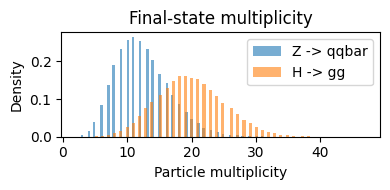

In [6]:
# Quick sanity check: plot multiplicity distributions
fig, ax = plt.subplots(figsize=(4, 2))
ax.hist(mults_Z, bins=90, alpha=0.6, label='Z -> qqbar', density=True)
ax.hist(mults_H, bins=90, alpha=0.6, label='H -> gg', density=True)
ax.set_xlabel('Particle multiplicity')
ax.set_ylabel('Density')
ax.set_title('Final-state multiplicity')
ax.legend()
plt.tight_layout()
plt.show()

# Uniform Phase Space

In [7]:
NEvents=100_000
uniform_N3 = gen_massless_phase_space(NEvents,3,energy=1.0)
uniform_N5 = gen_massless_phase_space(NEvents,5,energy=1.0)
uniform_N7 = gen_massless_phase_space(NEvents,7,energy=1.0)
uniform_N10 = gen_massless_phase_space(NEvents,10,energy=1.0)

# efpset = EFPSet(('d<=', 6), measure='eeefm', beta=2,coords='epxpypz')

# Plot some Kinematics

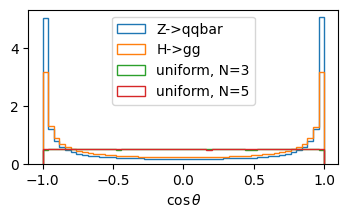

In [8]:
cos_theta_Z  = np.concatenate([e[:, 3] / np.linalg.norm(e[:, 1:4], axis=1) for e in Zqq_events])
cos_theta_H  = np.concatenate([e[:, 3] / np.linalg.norm(e[:, 1:4], axis=1) for e in Hgg_events])
cos_theta_u3 = np.concatenate([e[:, 3] / np.linalg.norm(e[:, 1:4], axis=1) for e in uniform_N3])
cos_theta_u5 = np.concatenate([e[:, 3] / np.linalg.norm(e[:, 1:4], axis=1) for e in uniform_N5])

fig, ax = plt.subplots(figsize=(4, 2))
plt.hist(cos_theta_Z, bins=50, alpha=1, density=True, histtype='step', label='Z->qqbar')
plt.hist(cos_theta_H, bins=50, alpha=1, density=True, histtype='step', label='H->gg')
plt.hist(cos_theta_u3, bins=50, alpha=1, density=True, histtype='step', label='uniform, N=3')
plt.hist(cos_theta_u5, bins=50, alpha=1, density=True, histtype='step', label='uniform, N=5')
plt.xlabel(r'$\cos\theta$'); 
plt.legend(); 
plt.show()

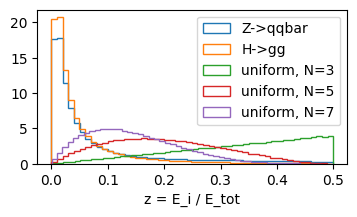

In [9]:
z_Z  = np.concatenate([e[:, 0] / e[:, 0].sum() for e in Zqq_events])
z_H  = np.concatenate([e[:, 0] / e[:, 0].sum() for e in Hgg_events])
z_u3 = np.concatenate([e[:, 0] / e[:, 0].sum() for e in uniform_N3])
z_u5 = np.concatenate([e[:, 0] / e[:, 0].sum() for e in uniform_N5])
z_u7 = np.concatenate([e[:, 0] / e[:, 0].sum() for e in uniform_N7])

fig, ax = plt.subplots(figsize=(4, 2))
plt.hist(z_Z, bins=50, alpha=1, density=True, histtype='step', label='Z->qqbar')
plt.hist(z_H, bins=50, alpha=1, density=True, histtype='step', label='H->gg')
plt.hist(z_u3, bins=50, alpha=1, density=True, histtype='step', label='uniform, N=3')
plt.hist(z_u5, bins=50, alpha=1, density=True, histtype='step', label='uniform, N=5')
plt.hist(z_u7, bins=50, alpha=1, density=True, histtype='step', label='uniform, N=7')

plt.xlabel('z = E_i / E_tot'); 
plt.legend(); 
plt.show()


# Compute EFPs

Using `measure='ee'` (appropriate for e+e- events), which uses energy fractions z_i = E_i / sum(E_j) and pairwise angles theta_ij computed from the 3-momenta directions.

Input to `batch_compute`: list of (N_particles, 4) arrays with columns (E, px, py, pz).

In [10]:
EFPs_N3_restricted = efps_chunked(uniform_N3, dmax=8, device='cpu', chunk=5000).numpy()
EFPs_N5_restricted = efps_chunked(uniform_N5, dmax=8, device='cpu', chunk=5000).numpy()
EFPs_N7_restricted = efps_chunked(uniform_N7, dmax=8, device='cpu', chunk=5000).numpy()
EFPs_N10_restricted = efps_chunked(uniform_N10, dmax=8, device='cpu', chunk=5000).numpy()
print(f'Restricted EFP basis: {EFPs_N3_restricted.shape} EFPs')

Restricted EFP basis: (100000, 32) EFPs


In [11]:
efpset = ef.EFPSet(('d<=', 4),  measure='eeefm', beta=2, normed=True, coords='epxpypz')
print(f'EFP basis: {efpset.count()} EFPs')

EFPs_N3 = efpset.batch_compute(uniform_N3);   print('uniform N=3 done')
EFPs_N5 = efpset.batch_compute(uniform_N5);   print('uniform N=5 done')
EFPs_N7 = efpset.batch_compute(uniform_N7);   print('uniform N=7 done')
EFPs_N10 = efpset.batch_compute(uniform_N10);   print('uniform N=10 done')

EFPs_Zqq = efpset.batch_compute(Zqq_events); print('Z->qqbar done')
EFPs_Hgg = efpset.batch_compute(Hgg_events); print('H->gg done')


EFP basis: 36 EFPs
uniform N=3 done
uniform N=5 done
uniform N=7 done
uniform N=10 done
Z->qqbar done
H->gg done


In [12]:
####################
## Composite EFPs ##
####################
EFPs_N3_restricted_composite = np.einsum('na,nb->nab', EFPs_N3_restricted, EFPs_N3_restricted).reshape(len(EFPs_N3_restricted), -1)
EFPs_N5_restricted_composite = np.einsum('na,nb->nab', EFPs_N5_restricted, EFPs_N5_restricted).reshape(len(EFPs_N5_restricted), -1)
EFPs_N7_restricted_composite = np.einsum('na,nb->nab', EFPs_N7_restricted, EFPs_N7_restricted).reshape(len(EFPs_N7_restricted), -1)
EFPs_N10_restricted_composite = np.einsum('na,nb->nab', EFPs_N10_restricted, EFPs_N10_restricted).reshape(len(EFPs_N10_restricted), -1)
print(EFPs_N5_restricted_composite.shape)  

EFPs_N3_composite = np.einsum('na,nb->nab', EFPs_N3, EFPs_N3).reshape(len(EFPs_N3), -1)
EFPs_N5_composite = np.einsum('na,nb->nab', EFPs_N5, EFPs_N5).reshape(len(EFPs_N5), -1)
EFPs_N7_composite = np.einsum('na,nb->nab', EFPs_N7, EFPs_N7).reshape(len(EFPs_N7), -1)
EFPs_N10_composite = np.einsum('na,nb->nab', EFPs_N10, EFPs_N10).reshape(len(EFPs_N10), -1)
EFPs_Zqq_composite = np.einsum('na,nb->nab', EFPs_Zqq, EFPs_Zqq).reshape(len(EFPs_Zqq), -1)
EFPs_Hgg_composite = np.einsum('na,nb->nab', EFPs_Hgg, EFPs_Hgg).reshape(len(EFPs_Hgg), -1)

print(EFPs_N5_composite.shape)  


(100000, 1024)
(100000, 1296)


In [13]:
# efpset_d4Beta1 = ef.EFPSet('d<=4', measure='ee', beta=1, normed=True)
# efpset_d4Beta2 = ef.EFPSet('d<=4', measure='ee', beta=2, normed=True)
# efpset_d5Beta1 = ef.EFPSet('d<=5', measure='ee', beta=1, normed=True)
# efpset_d5Beta2 = ef.EFPSet('d<=5', measure='ee', beta=2, normed=True)

# configs = [
#     ('d4b1', efpset_d4Beta1, r'$d_{\leq 4},\ \beta=1$'),
#     ('d4b2', efpset_d4Beta2, r'$d_{\leq 4},\ \beta=2$'),
#     ('d5b1', efpset_d5Beta1, r'$d_{\leq 5},\ \beta=1$'),
#     ('d5b2', efpset_d5Beta2, r'$d_{\leq 5},\ \beta=2$'),
# ]

# efps_all = {}
# for key, efpset, label in configs:
#     Z = efpset.batch_compute(Zqq_events)
#     H = efpset.batch_compute(Hgg_events)
#     efps_all[key] = {'Z': Z, 'H': H, 'label': label}
#     print(f'{key}: n_EFPs={Z.shape[1]}')

In [14]:
# Log
eps = 1e-10
log_EFPs_Zqq = np.log(EFPs_Zqq + eps)
log_EFPs_Hgg = np.log(EFPs_Hgg + eps)
log_EFPs_N3  = np.log(EFPs_N3  + eps)
log_EFPs_N5  = np.log(EFPs_N5  + eps)
log_EFPs_N7  = np.log(EFPs_N7  + eps)
log_EFPs_N10  = np.log(EFPs_N10  + eps)


## Covariance Matrix

In [15]:
cov_u3 = np.cov(EFPs_N3.T)
cov_u5 = np.cov(EFPs_N5.T)
cov_u7 = np.cov(EFPs_N7.T)
cov_u10 = np.cov(EFPs_N10.T)
cov_Z = np.cov(EFPs_Zqq.T) 
cov_H = np.cov(EFPs_Hgg.T)

cov_u3_comp = np.cov(EFPs_N3_composite.T)
cov_u5_comp = np.cov(EFPs_N5_composite.T)
cov_u7_comp = np.cov(EFPs_N7_composite.T)
cov_u10_comp = np.cov(EFPs_N10_composite.T)
cov_Z_comp = np.cov(EFPs_Zqq_composite.T) 
cov_H_comp = np.cov(EFPs_Hgg_composite.T)

print(f'Covariance matrix shape: {cov_Z.shape}')

Covariance matrix shape: (36, 36)


## Eigenspectrum

Diagonalize each covariance matrix and plot eigenvalues sorted in descending order.
The shape of this spectrum reflects how correlated the EFPs are — a steep drop means
most variance is captured by the first few eigenvectors.

In [16]:
samples = [('Z->qqbar', cov_Z), ('H->gg', cov_H),
           ('uniform N=3', cov_u3), ('uniform N=5', cov_u5),
           ('uniform N=7', cov_u7), ('uniform N=10', cov_u10)]

samples_comp = [('Z->qqbar', cov_Z_comp), ('H->gg', cov_H_comp),
                ('uniform N=3', cov_u3_comp), ('uniform N=5', cov_u5_comp),
                ('uniform N=7', cov_u7_comp), ('uniform N=10', cov_u10_comp)]

eigvals, eigvals_comp = {}, {}
for name, cov in samples:
    ev = np.clip(np.sort(np.linalg.eigvalsh(cov))[::-1], 0, None)
    eigvals[name] = ev
    print(f'{name}: largest = {ev[0]:.4e}, smallest = {ev[-1]:.4e}')
for name, cov in samples_comp:
    ev = np.clip(np.sort(np.linalg.eigvalsh(cov))[::-1], 0, None)
    eigvals_comp[name] = ev
    print(f'{name}: largest = {ev[0]:.4e}, smallest = {ev[-1]:.4e}')

Z->qqbar: largest = 5.5481e+02, smallest = 0.0000e+00
H->gg: largest = 6.2032e+02, smallest = 0.0000e+00
uniform N=3: largest = 8.0778e+02, smallest = 0.0000e+00
uniform N=5: largest = 3.9052e+02, smallest = 0.0000e+00
uniform N=7: largest = 2.0577e+02, smallest = 0.0000e+00
uniform N=10: largest = 1.0231e+02, smallest = 0.0000e+00
Z->qqbar: largest = 5.7330e+07, smallest = 0.0000e+00
H->gg: largest = 5.2999e+07, smallest = 0.0000e+00
uniform N=3: largest = 7.6296e+07, smallest = 0.0000e+00
uniform N=5: largest = 2.7759e+07, smallest = 0.0000e+00
uniform N=7: largest = 1.2616e+07, smallest = 0.0000e+00
uniform N=10: largest = 5.5640e+06, smallest = 0.0000e+00


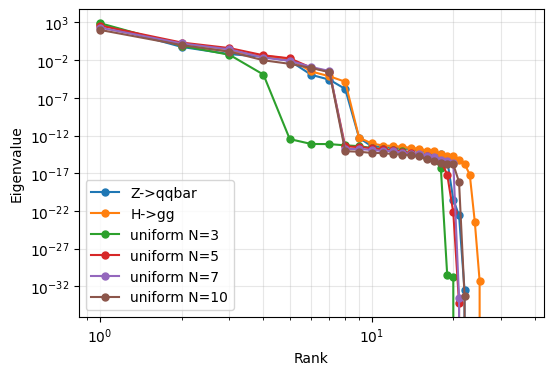

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, ev in eigvals.items():
    ax.loglog(np.arange(1, len(ev)+1), ev, '.-', markersize=10, label=name)
ax.set_xlabel('Rank'); 
ax.set_ylabel('Eigenvalue')
ax.legend(); 
ax.grid(True, which='both', alpha=0.3)

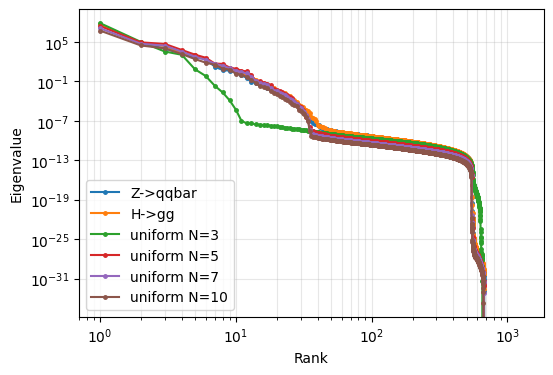

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, ev in eigvals_comp.items():
    ax.loglog(np.arange(1, len(ev)+1), ev, '.-', markersize=5, label=name)
ax.set_xlabel('Rank'); 
ax.set_ylabel('Eigenvalue')
ax.legend(); 
ax.grid(True, which='both', alpha=0.3)

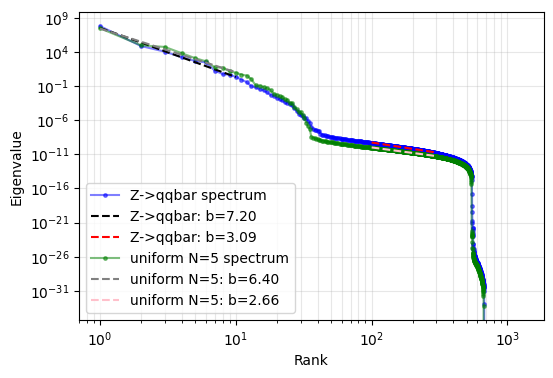

In [15]:
fit_min, fit_max = 1, 10
fit_min2, fit_max2 = 100, 300

fig, ax = plt.subplots(figsize=(6, 4))
for name, color0, color1, color2 in [('Z->qqbar', 'b', 'k','r'), 
                    # ('H->gg', 'r'), 
                    ('uniform N=5', 'g', 'gray', 'pink')]:
    ev = eigvals[name]
    idx = np.arange(1, len(ev)+1)
    ax.loglog(idx, ev, '.-', markersize=5, color=color0, label=f'{name} spectrum', alpha=0.5)
    mask = (idx >= fit_min) & (idx <= fit_max) & (ev > 0)
    mask2 = (idx >= fit_min2) & (idx <= fit_max2) & (ev > 0)
    slope, log_c = np.polyfit(np.log(idx[mask]), np.log(ev[mask]), 1)
    slope2, log_c2 = np.polyfit(np.log(idx[mask2]), np.log(ev[mask2]), 1)
    ax.loglog(idx[mask], np.exp(log_c)*idx[mask]**slope, '--', color=color1,
              label=f'{name}: b={-slope:.2f}', alpha=1)
    ax.loglog(idx[mask2], np.exp(log_c2)*idx[mask2]**slope2, '--', color=color2,
              label=f'{name}: b={-slope2:.2f}', alpha=1)
ax.set_xlabel('Rank'); 
ax.set_ylabel('Eigenvalue')
ax.legend(); 
ax.grid(True, which='both', alpha=0.3)

In [16]:
# _, U_Z = np.linalg.eigh(cov_Z)
# _, U_N5 = np.linalg.eigh(cov_u5)
# overlap = np.abs(U_Z.T @ U_N5)  # shape (102, 102)
# plt.imshow(overlap, vmin=0, vmax=1, cmap='hot')
# plt.colorbar(); plt.title('|eigvec overlap| Z vs uniform N=5')
# plt.show()


## Linear Regression: EFPs → Quark/Gluon Label

Combine both samples with labels 0 (Z→qqbar) and 1 (H→gg). Train linear regression on
subsets of increasing size and plot test loss vs number of training events.

In [17]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np

# Combine log EFPs and labels
X = np.vstack([EFPs_Zqq, EFPs_Hgg])
y = np.array([0] * len(EFPs_Zqq) + [1] * len(EFPs_Hgg), dtype=float)

rng = np.random.default_rng(42)
idx = rng.permutation(len(X))
X, y = X[idx], y[idx]

X_test, y_test   = X[-20000:], y[-20000:]
X_train, y_train = X[:-20000], y[:-20000]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Fixed ridge penalty r — RidgeCV selects r optimal for large N,
# which is too small for small-N subsets and causes instability.
# r = RidgeCV(alphas=np.logspace(-4, 4, 50), cv=5).fit(X_train_s, y_train).alpha_
r = 1e-2
print(f'Fixed ridge r = {r:.4e}')

train_sizes = [5, 8, 10, 15, 25, 50, 75, 100, 150, 200, 300, 500, 700, 1000, 1500, 2000, 3000, 5000, 8000]
train_sizes = [5, 8, 10, 15, 25, 50, 75, 100, 150, 200, 300, 500, 700, 1000, 1500, 2000, 3000, 5000, 8000, 15000, 30000, 60000, 120000, 160000]
test_losses = []
n_repeats = 500

print("Train size | Test MSE (avg over repeats)")
for n in train_sizes:
    losses_n = []
    for seed in range(n_repeats):
        sub_idx = np.random.default_rng(seed).choice(len(X_train_s), size=n, replace=False)
        reg = Ridge(alpha=r).fit(X_train_s[sub_idx], y_train[sub_idx])
        losses_n.append(mean_squared_error(y_test, reg.predict(X_test_s)))
    mean_loss = np.mean(losses_n)
    test_losses.append(mean_loss)
    print(f"  {n:6d}   |  {mean_loss:.6f}")

Fixed ridge r = 1.0000e-02
Train size | Test MSE (avg over repeats)
       5   |  0.410684
       8   |  0.302493
      10   |  0.286856
      15   |  0.238921
      25   |  0.206643
      50   |  0.183562


KeyboardInterrupt: 

Estimated irreducible floor: 0.159213


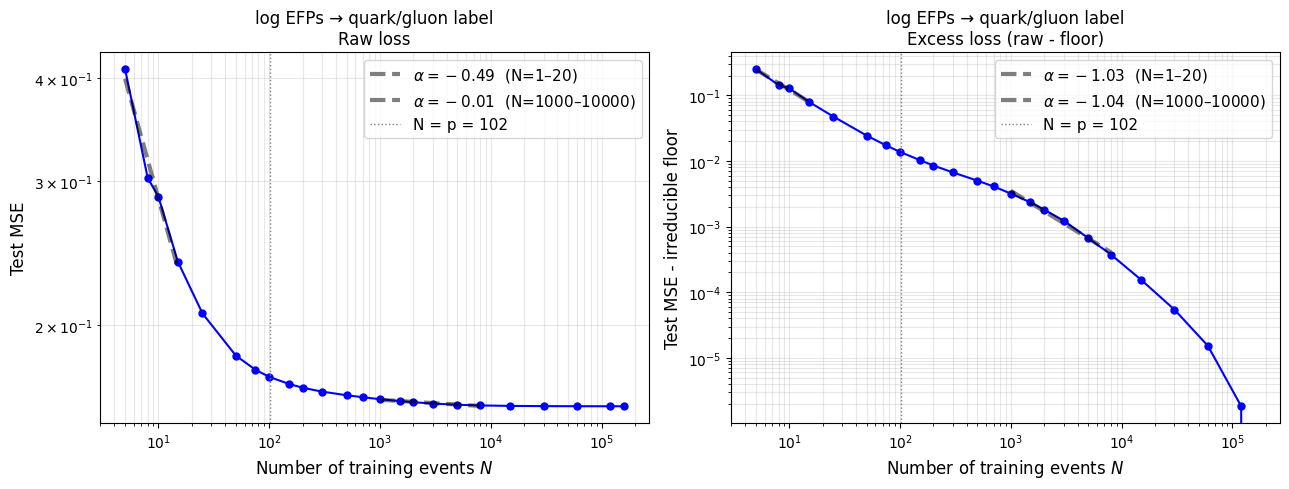

In [27]:
fit_n_min_1 = 1
fit_n_max_1 = 20

fit_n_min_2 = 1000
fit_n_max_2 = 10000

floor = test_losses[-1]
excess_losses = [l - floor for l in test_losses]
print(f'Estimated irreducible floor: {floor:.6f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, losses, title, ylabel, exclude_last in zip(
    axes,
    [test_losses, excess_losses],
    ['Raw loss', 'Excess loss (raw - floor)'],
    ['Test MSE', 'Test MSE - irreducible floor'],
    [False, True]
):
    ax.loglog(train_sizes, losses, 'bo-', markersize=5)

    ns_all = train_sizes[:-1] if exclude_last else train_sizes
    ls_all = losses[:-1]      if exclude_last else losses

    mask_1 = [fit_n_min_1 <= n <= fit_n_max_1 for n in ns_all]
    ns_fit_1 = [n for n, m in zip(ns_all, mask_1) if m]
    ls_fit_1 = [l for l, m in zip(ls_all, mask_1) if m]

    mask_2 = [fit_n_min_2 <= n <= fit_n_max_2 for n in ns_all]
    ns_fit_2 = [n for n, m in zip(ns_all, mask_2) if m]
    ls_fit_2 = [l for l, m in zip(ls_all, mask_2) if m]

    if len(ns_fit_1) >= 2:
        slope_1, log_c_1 = np.polyfit(np.log(ns_fit_1), np.log(ls_fit_1), 1)
        ax.loglog(ns_fit_1, np.exp(log_c_1) * np.array(ns_fit_1)**slope_1, 'k--', linewidth=3, alpha=0.5,
                  label=f'$\\alpha = {slope_1:.2f}$  (N={fit_n_min_1}–{fit_n_max_1})')
        
    if len(ns_fit_2) >= 2:
        slope_2, log_c_2 = np.polyfit(np.log(ns_fit_2), np.log(ls_fit_2), 1)
        ax.loglog(ns_fit_2, np.exp(log_c_2) * np.array(ns_fit_2)**slope_2, 'k--', linewidth=3, alpha=0.5,
                  label=f'$\\alpha = {slope_2:.2f}$  (N={fit_n_min_2}–{fit_n_max_2})')

    ax.axvline(102, color='gray', linestyle=':', linewidth=1, label='N = p = 102')
    ax.set_xlabel('Number of training events $N$', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'log EFPs → quark/gluon label\n{title}', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/scaling_law_label.png', dpi=150, bbox_inches='tight')
plt.show()

## Linear Regression: EFPs → Thrust

Thrust is IRC-safe and well-approximated by low-d EFPs, so the irreducible floor should be near zero.

In [20]:
def compute_thrust(event):
    """Thrust for an e+e- event. event: (N,4) array (E,px,py,pz)."""
    momenta = event[:, 1:4]                      # \vec{p}
    norms = np.linalg.norm(momenta, axis=1)      # |\vec{p}|
    momenta = momenta[norms> 1e-10]             # get rid of 
    norms = norms[norms > 1e-10]                 # particles with 0 norm ... 
    denom = np.sum(norms)                        # sum_i |p_i| 
    best_T = 0.
    for i in range(len(momenta)):                  # only scanning over momenta in the event ...  
        n = momenta[i] / norms[i]                  # \hat{p}
        T = np.sum(np.abs(momenta @ n)) / denom    # sum_i |  |
        if T > best_T:
            best_T = T
    return best_T


def compute_thrust_iterative(event, max_iter=20):
    """Exact thrust via iterated hemisphere refinement. event: (N,4) array (E,px,py,pz)."""
    momenta = event[:, 1:4]                        # \vec{p}
    norms = np.linalg.norm(momenta, axis=1)        # |\vec{p}|
    momenta = momenta[norms > 1e-10]
    norms = norms[norms > 1e-10]
    denom = np.sum(norms)     
    best_T = 0.
    for i in range(len(momenta)):
        n = momenta[i] / norms[i]
        for _ in range(max_iter):
            signs = np.sign(momenta @ n)       # assigns each momenta to a hemisphere +/-
            signs[signs == 0] = 1.
            n_new = signs @ momenta            # optimal axis is sum of momenta on + hemisphere
            norm_new = np.linalg.norm(n_new) 
            if norm_new < 1e-10:
                break
            n_new /= norm_new
            if np.abs(1. - np.abs(n_new @ n)) < 1e-12:  # check convergence
                break
            n = n_new
        T = np.sum(np.abs(momenta @ n)) / denom
        if T > best_T:
            best_T = T
    return best_T

In [21]:
thrust_samples = {
    'Z->qqbar':    Zqq_events,
    'H->gg':       Hgg_events,
    'uniform N=3': uniform_N3,
    'uniform N=5': uniform_N5,
    'uniform N=7': uniform_N7,
    'uniform N=10': uniform_N10,
}

thrusts = {}
for name, events in thrust_samples.items():
    t = np.array([compute_thrust(e) for e in events])
    thrusts[name] = t
    print(f'{name}: mean thrust = {np.mean(t):.4f} +/- {np.std(t):.4f}')


Z->qqbar: mean thrust = 0.9351 +/- 0.0631
H->gg: mean thrust = 0.8612 +/- 0.0826
uniform N=3: mean thrust = 0.8888 +/- 0.0784
uniform N=5: mean thrust = 0.7701 +/- 0.0883
uniform N=7: mean thrust = 0.7217 +/- 0.0777
uniform N=10: mean thrust = 0.6852 +/- 0.0654


In [33]:
Ps_C = [5, 10, 25, 50, 100, 300, 500, 1000, 3000, 5000, 7000, 9000, 10000, 20000, 40000, 60000, 80000]
# train_sizes_t = np.unique(np.round(np.logspace(0, 4.5, 90)).astype(int))   # training sizes to sweep
λs = [1e-10]
n_reps = lambda P: max(int(1000 / P), 10)
losses_Z_comp, losses_N3_comp, losses_N5_comp, losses_N10_comp = {}, {}, {}, {}
for λ in λs: 
    # losses_Z[r]  = run_torch_regression(EFPs_Zqq_composite, thrusts['Z->qqbar'],    train_sizes_t, r=r)
    # losses_N3[r] = run_torch_regression(EFPs_N3_composite,  thrusts['uniform N=3'], train_sizes_t, r=r)
    losses_N5_comp[λ] = run_regression_sweep(EFPs_N5_composite,  thrusts['uniform N=5'], Ps_C, λ=λ, n_repeats=n_reps, test_size=0.2, 
                                        w_true=None, filter_zero_var=False, center=False, scale=False)
    losses_N10_comp[λ] = run_regression_sweep(EFPs_N10_composite,  thrusts['uniform N=10'], Ps_C, λ=λ, n_repeats=n_reps, test_size=0.2, 
                                         w_true=None, filter_zero_var=False, center=False, scale=False)


       5  |  0.009008
      10  |  0.014144
      25  |  0.066165
      50  |  23.525497
     100  |  0.088275
     300  |  2.400184
     500  |  3.256433
    1000  |  0.021714
    3000  |  0.000219
    5000  |  0.000219
    7000  |  0.000218
    9000  |  0.000219
   10000  |  0.000218
   20000  |  0.000218
   40000  |  0.000224
   60000  |  0.000217
   80000  |  0.000231
       5  |  0.008331
      10  |  0.029165
      25  |  0.268315
      50  |  0.974753
     100  |  0.079252
     300  |  0.077832
     500  |  0.091520
    1000  |  2.837861
    3000  |  0.000282
    5000  |  0.000281
    7000  |  0.000280
    9000  |  0.000280
   10000  |  0.000279
   20000  |  0.000278
   40000  |  0.000277
   60000  |  0.000277
   80000  |  0.000277


In [24]:
print(np.shape(EFPs_N5_composite))
print(np.shape(EFPs_N5))

(100000, 1296)
(100000, 36)


Text(0.5, 0, 'EFP Value')

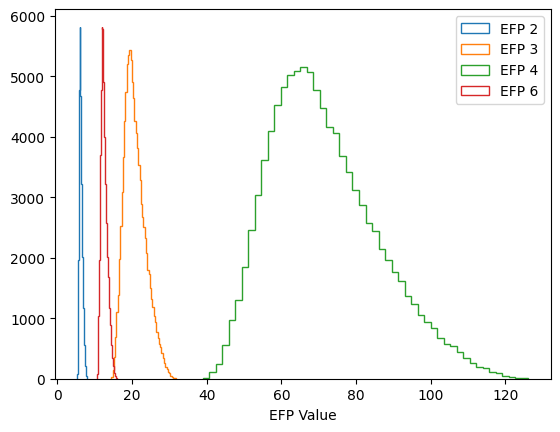

In [107]:
## Plot features ... 
plt.hist(EFPs_N5[:, 2], bins=50, histtype='step', label='EFP 2')
plt.hist(EFPs_N5[:, 3], bins=50, histtype='step', label='EFP 3')
plt.hist(EFPs_N5[:, 4], bins=50, histtype='step', label='EFP 4')
plt.hist(EFPs_N5[:, 6], bins=50, histtype='step', label='EFP 6')
plt.legend(); plt.xlabel('EFP Value')


In [ ]:
train_sizes_t = [5, 10, 25, 50, 100, 300, 500, 1000, 3000, 5000, 7000, 9000, 10000, 20000, 40000, 60000, 80000]
Ps_NC = np.unique(np.round(np.logspace(0, 4.5, 50)).astype(int))   
λs = [1e-10]
n_reps = lambda P: max(int(10000 / P), 100)
losses_Z, losses_N3, losses_N5, losses_N10 = {}, {}, {}, {}
for λ in λs: 
    # losses_Z[λ]  = run_regression_sweep(EFPs_Zqq, thrusts['Z->qqbar'],  Ps_NC, λ=λ, n_repeats=n_reps, test_size=0.2, 
    #                                     w_true=None, filter_zero_var=True, center=False, scale=False)
    # losses_N3[r] = run_torch_regression(EFPs_N3_composite,  thrusts['uniform N=3'], train_sizes_t, r=r)
    losses_N5[λ] = run_regression_sweep(EFPs_N5,  thrusts['uniform N=5'], Ps_NC, λ=λ, n_repeats=n_reps, test_size=0.2, 
                                        w_true=None, filter_zero_var=True, center=True, scale=True)
    losses_N10[λ] = run_regression_sweep(EFPs_N10,  thrusts['uniform N=10'], Ps_NC, λ=λ, n_repeats=n_reps, test_size=0.2, 
                                         w_true=None, filter_zero_var=True, center=True, scale=True)

       1  |  0.015681
       2  |  0.013900
       3  |  0.019364
       4  |  0.019208
       5  |  0.025402
       6  |  0.049124
       7  |  1.019863
       8  |  0.028651
       9  |  0.010582
      10  |  0.005819
      12  |  0.003611
      13  |  0.003117
      15  |  0.002352
      16  |  0.002116
      18  |  0.001845
      21  |  0.001459
      23  |  0.001255
      26  |  0.001119
      29  |  0.001021
      33  |  0.000916
      37  |  0.000806
      41  |  0.000771
      47  |  0.000691
      52  |  0.000633
      59  |  0.000575
      66  |  0.000552
      74  |  0.000534
      83  |  0.000504
      94  |  0.000490
     105  |  0.000474
     118  |  0.000457
     133  |  0.000447
     149  |  0.000431
     168  |  0.000427
     188  |  0.000417
     212  |  0.000412
     238  |  0.000405
     267  |  0.000402
     300  |  0.000392
     337  |  0.000392
     379  |  0.000386
     426  |  0.000383
     478  |  0.000382
     537  |  0.000377
     604  |  0.000374
     678  

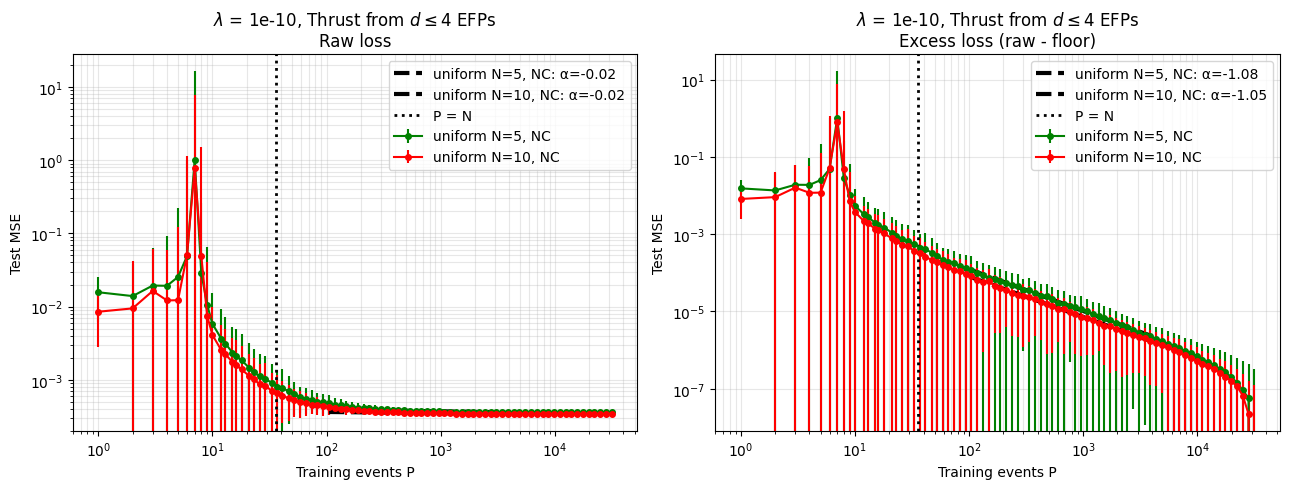

In [143]:
fit_min, fit_max = 100, 4000
ridgeparam=1e-10
all_results = {
    # 'Z->qqbar NC':    losses_Z[ridgeparam],
    # 'uniform N=3': losses_N3[ridgeparam],
    'uniform N=5, NC': losses_N5[ridgeparam],
    'uniform N=10, NC': losses_N10[ridgeparam],
    # 'uniform N=5, C': losses_N5_comp[ridgeparam],
    # 'uniform N=10, C': losses_N10_comp[ridgeparam],
}
colors = {
    # 'Z->qqbar NC': 'pink', 
        #   'uniform N=3': 'b',
            'uniform N=5, NC': 'g',
            'uniform N=10, NC': 'r',
    # 'uniform N=5, C': 'b',
    # 'uniform N=10, C': 'orange'
            }

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, (losses, stds) in all_results.items():
    color = colors[name]
    floor = losses[-1]
    excess = np.array(losses) - floor
    ps = np.array(Ps_NC) if name[-2]=='N' else np.array(Ps_C)
    err1 = stds/np.sqrt(np.array([n_reps(p) for p in ps]))
    err2 = stds

    # axes[0].loglog(ps, losses, 'o-', color=color, markersize=4, label=name)
    # axes[1].loglog(ps, excess, 'o-', color=color, markersize=4, label=name)
    axes[0].errorbar(ps, losses, yerr=err2, fmt='o-', color=color, markersize=4, label=name)
    axes[1].errorbar(ps, excess, yerr=err2, fmt='o-', color=color, markersize=4, label=name)
    axes[0].set_xscale('log'); axes[0].set_yscale('log')
    axes[1].set_xscale('log'); axes[1].set_yscale('log')

    for ax, ls in zip(axes, [np.array(losses), excess]):
        mask = (ps >= fit_min) & (ps <= fit_max) & (ls > 0)
        if mask.sum() >= 2:
            slope, log_c = np.polyfit(np.log(ps[mask]), np.log(ls[mask]), 1, w=ls[mask]/err1[mask])

            ax.loglog(ps[mask], np.exp(log_c)*ps[mask]**slope, '--', color='k', linewidth=3,
                      label=f'{name}: α={slope:.2f}')
            # ax.axvspan(fit_min, fit_max, alpha=0.05, color=color)

for ax, title in zip(axes, ['Raw loss', 'Excess loss (raw - floor)']):
    # ax.set_ylim(1e-15, 1e1)
    ax.axvline(np.shape(EFPs_N5)[1], color='k', linestyle=':', linewidth=2, label='P = N')
    ax.set_xlabel('Training events P'); ax.set_ylabel('Test MSE')
    ax.set_title(f'$\lambda$ = 1e-10, Thrust from $d\leq 4$ EFPs\n{title}'); ax.legend(); ax.grid(True, which='both', alpha=0.3)

plt.tight_layout(); plt.show()

426 31623


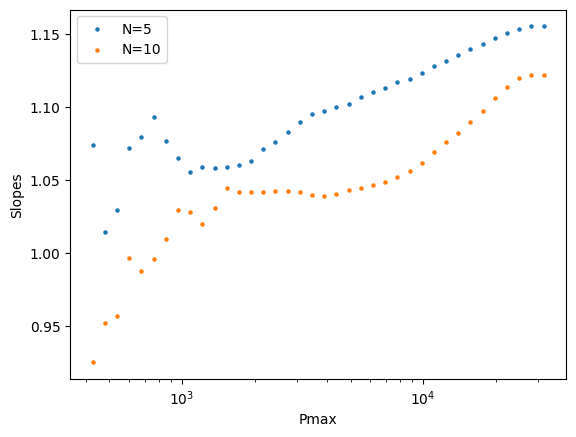

In [144]:
Pmin = 200
Pmaxes = Ps_NC[Ps_NC > 2*Pmin]
print(min(Pmaxes), max(Pmaxes))
ns = np.array(Ps_NC)
slopes5, slopes10 = [], []
for p in Pmaxes:
    fit_min, fit_max = Pmin, p
    losses5, losses10 = all_results['uniform N=5, NC'][0], all_results['uniform N=10, NC'][0]
    std5, std10 = all_results['uniform N=5, NC'][1], all_results['uniform N=10, NC'][1]
    ls5 = np.array(losses5) - losses5[-1]
    ls10 = np.array(losses10) - losses10[-1]
    err1_5, err2_5 = std5/np.sqrt(np.array([n_reps(p) for p in Ps_NC])), std5
    err1_10, err2_10 = std10/np.sqrt(np.array([n_reps(p) for p in Ps_NC])), std10
    mask5 = (Ps_NC >= fit_min) & (Ps_NC <= fit_max) & (ls5 > 0)
    mask10= (Ps_NC >= fit_min) & (Ps_NC <= fit_max) & (ls10 > 0)
    slopes5.append(-np.polyfit(np.log(Ps_NC[mask5]), np.log(ls5[mask5]), 1, w=ls5[mask5]/err1_5[mask5])[0])
    slopes10.append(-np.polyfit(np.log(Ps_NC[mask10]), np.log(ls10[mask10]), 1, w=ls10[mask10]/err1_10[mask10])[0])
plt.scatter(Pmaxes, slopes5, s=5)
plt.scatter(Pmaxes, slopes10, s=5)
plt.xscale('log'); plt.xlabel('Pmax'); plt.ylabel('Slopes'); plt.legend(['N=5', 'N=10'])

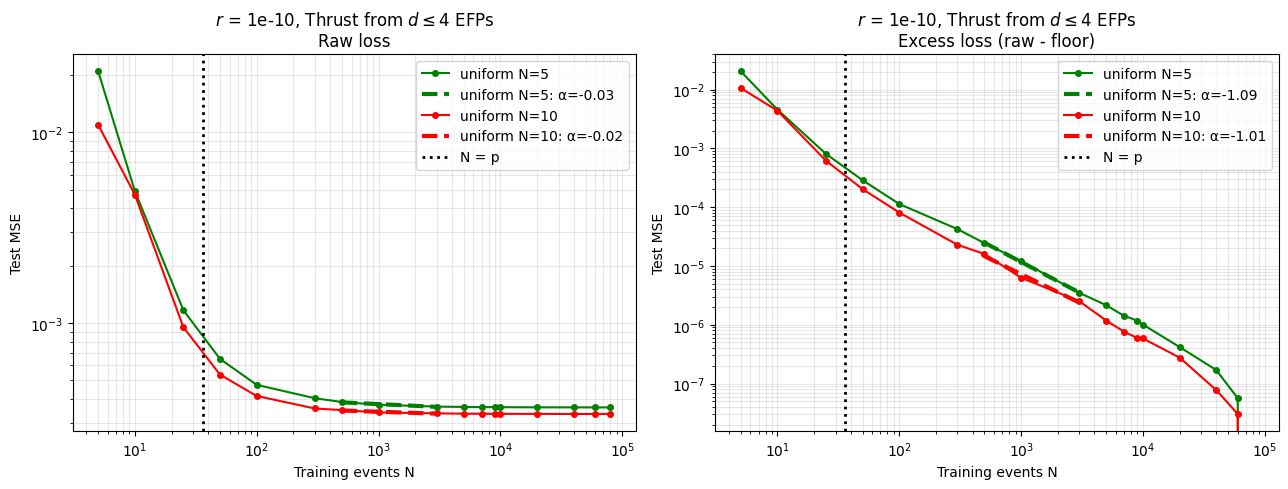

In [39]:
fit_min, fit_max = 500, 3000
ridgeparam=1e-10
all_results = {
    # 'Z->qqbar':    losses_Z[ridgeparam],
    # 'uniform N=3': losses_N3[ridgeparam],
    'uniform N=5': losses_N5_nc[ridgeparam],
    'uniform N=10': losses_N10_nc[ridgeparam],
}
colors = {
    # 'Z->qqbar': 'k', 
        #   'uniform N=3': 'b',
            'uniform N=5': 'g',
            'uniform N=10': 'r',
            }

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, losses in all_results.items():
    color = colors[name]
    floor = losses[-1]
    excess = np.array(losses) - floor
    ns = np.array(train_sizes_t)

    axes[0].loglog(ns, losses, 'o-', color=color, markersize=4, label=name)
    axes[1].loglog(ns, excess, 'o-', color=color, markersize=4, label=name)

    for ax, ls in zip(axes, [np.array(losses), excess]):
        mask = (ns >= fit_min) & (ns <= fit_max) & (ls > 0)
        if mask.sum() >= 2:
            slope, log_c = np.polyfit(np.log(ns[mask]), np.log(ls[mask]), 1)
            ax.loglog(ns[mask], np.exp(log_c)*ns[mask]**slope, '--', color=color, linewidth=3,
                      label=f'{name}: α={slope:.2f}')
            # ax.axvspan(fit_min, fit_max, alpha=0.05, color=color)

for ax, title in zip(axes, ['Raw loss', 'Excess loss (raw - floor)']):
    ax.axvline(np.shape(EFPs_N5)[1], color='k', linestyle=':', linewidth=2, label='N = p')
    ax.set_xlabel('Training events N'); ax.set_ylabel('Test MSE')
    ax.set_title(f'$r$ = 1e-10, Thrust from $d\leq 4$ EFPs\n{title}'); ax.legend(); ax.grid(True, which='both', alpha=0.3)

plt.tight_layout(); plt.show()

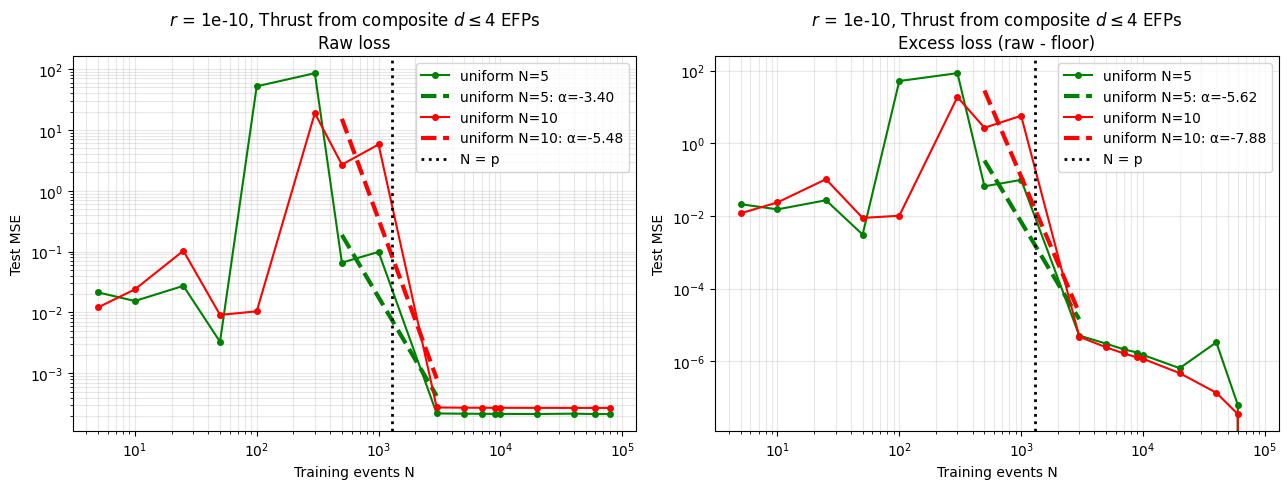

In [38]:
fit_min, fit_max = 500, 3000
ridgeparam=1e-10
all_results = {
    # 'Z->qqbar':    losses_Z[ridgeparam],
    # 'uniform N=3': losses_N3[ridgeparam],
    'uniform N=5': losses_N5[ridgeparam],
    'uniform N=10': losses_N10[ridgeparam],
}
colors = {
    # 'Z->qqbar': 'k', 
        #   'uniform N=3': 'b',
            'uniform N=5': 'g',
            'uniform N=10': 'r',
            }

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, losses in all_results.items():
    color = colors[name]
    floor = losses[-1]
    excess = np.array(losses) - floor
    ns = np.array(train_sizes_t)

    axes[0].loglog(ns, losses, 'o-', color=color, markersize=4, label=name)
    axes[1].loglog(ns, excess, 'o-', color=color, markersize=4, label=name)

    for ax, ls in zip(axes, [np.array(losses), excess]):
        mask = (ns >= fit_min) & (ns <= fit_max) & (ls > 0)
        if mask.sum() >= 2:
            slope, log_c = np.polyfit(np.log(ns[mask]), np.log(ls[mask]), 1)
            ax.loglog(ns[mask], np.exp(log_c)*ns[mask]**slope, '--', color=color, linewidth=3,
                      label=f'{name}: α={slope:.2f}')
            # ax.axvspan(fit_min, fit_max, alpha=0.05, color=color)

for ax, title in zip(axes, ['Raw loss', 'Excess loss (raw - floor)']):
    ax.axvline(np.shape(EFPs_N5_composite)[1], color='k', linestyle=':', linewidth=2, label='N = p')
    ax.set_xlabel('Training events N'); ax.set_ylabel('Test MSE')
    ax.set_title(f'$r$ = 1e-10, Thrust from composite $d\leq 4$ EFPs\n{title}'); ax.legend(); ax.grid(True, which='both', alpha=0.3)

plt.tight_layout(); plt.show()

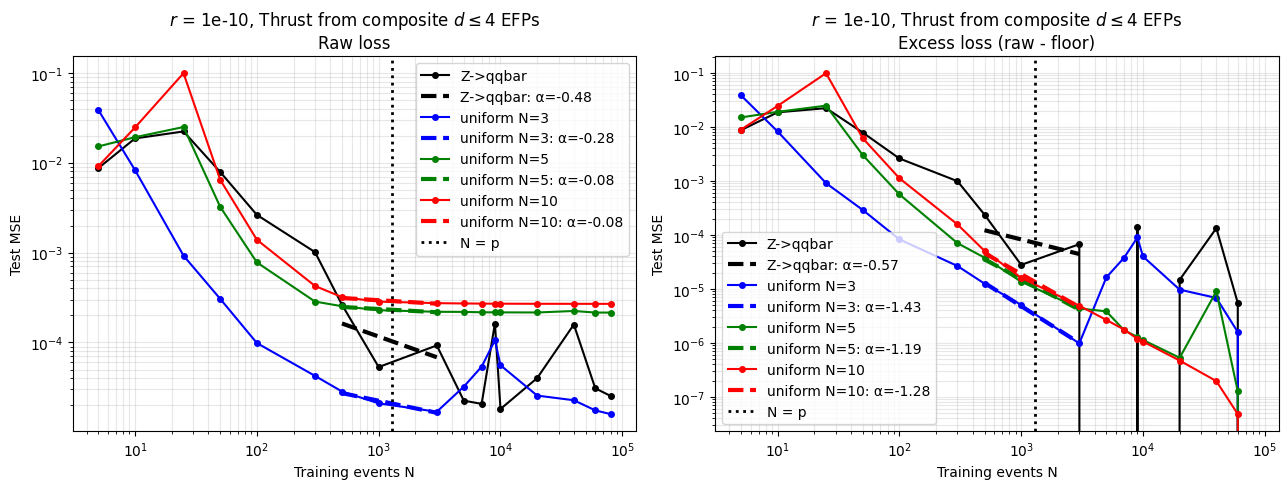

In [30]:
fit_min, fit_max = 500, 3000
ridgeparam=1e-10
all_results = {
    'Z->qqbar':    losses_Z[ridgeparam],
    'uniform N=3': losses_N3[ridgeparam],
    'uniform N=5': losses_N5[ridgeparam],
    'uniform N=10': losses_N10[ridgeparam],
}
colors = {'Z->qqbar': 'k', 
          'uniform N=3': 'b',
            'uniform N=5': 'g',
            'uniform N=10': 'r',
            }

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, losses in all_results.items():
    color = colors[name]
    floor = losses[-1]
    excess = np.array(losses) - floor
    ns = np.array(train_sizes_t)

    axes[0].loglog(ns, losses, 'o-', color=color, markersize=4, label=name)
    axes[1].loglog(ns, excess, 'o-', color=color, markersize=4, label=name)

    for ax, ls in zip(axes, [np.array(losses), excess]):
        mask = (ns >= fit_min) & (ns <= fit_max) & (ls > 0)
        if mask.sum() >= 2:
            slope, log_c = np.polyfit(np.log(ns[mask]), np.log(ls[mask]), 1)
            ax.loglog(ns[mask], np.exp(log_c)*ns[mask]**slope, '--', color=color, linewidth=3,
                      label=f'{name}: α={slope:.2f}')
            # ax.axvspan(fit_min, fit_max, alpha=0.05, color=color)

for ax, title in zip(axes, ['Raw loss', 'Excess loss (raw - floor)']):
    ax.axvline(1296, color='k', linestyle=':', linewidth=2, label='N = p')
    ax.set_xlabel('Training events N'); ax.set_ylabel('Test MSE')
    ax.set_title(f'$r$ = 1e-10, Thrust from composite $d\leq 4$ EFPs\n{title}'); ax.legend(); ax.grid(True, which='both', alpha=0.3)

plt.tight_layout(); plt.show()

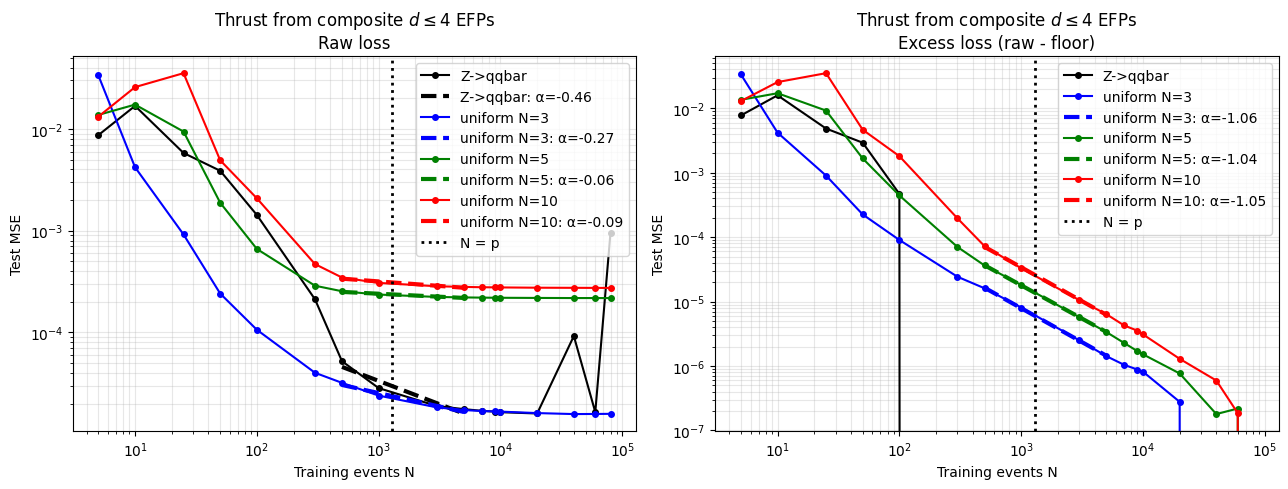

In [51]:
fit_min, fit_max = 500, 5000

all_results = {
    'Z->qqbar':    losses_Z,
    'uniform N=3': losses_N3,
    'uniform N=5': losses_N5,
    'uniform N=10': losses_N10,
}
colors = {'Z->qqbar': 'k', 
          'uniform N=3': 'b',
            'uniform N=5': 'g',
            'uniform N=10': 'r',
            }

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, losses in all_results.items():
    color = colors[name]
    floor = losses[-1]
    excess = np.array(losses) - floor
    ns = np.array(train_sizes_t)

    axes[0].loglog(ns, losses, 'o-', color=color, markersize=4, label=name)
    axes[1].loglog(ns, excess, 'o-', color=color, markersize=4, label=name)

    for ax, ls in zip(axes, [np.array(losses), excess]):
        mask = (ns >= fit_min) & (ns <= fit_max) & (ls > 0)
        if mask.sum() >= 2:
            slope, log_c = np.polyfit(np.log(ns[mask]), np.log(ls[mask]), 1)
            ax.loglog(ns[mask], np.exp(log_c)*ns[mask]**slope, '--', color=color, linewidth=3,
                      label=f'{name}: α={slope:.2f}')
            # ax.axvspan(fit_min, fit_max, alpha=0.05, color=color)

for ax, title in zip(axes, ['Raw loss', 'Excess loss (raw - floor)']):
    ax.axvline(1296, color='k', linestyle=':', linewidth=2, label='N = p')
    ax.set_xlabel('Training events N'); ax.set_ylabel('Test MSE')
    ax.set_title(f'Thrust from composite $d\leq 4$ EFPs\n{title}'); ax.legend(); ax.grid(True, which='both', alpha=0.3)

plt.tight_layout(); plt.show()

## Linear Regression: EFPs → C-parameter

In [191]:
def compute_C_parameter(event):
    momenta = event[:, 1:4]
    norms = np.linalg.norm(momenta, axis=1)
    momenta = momenta[norms > 1e-10]
    norms = norms[norms > 1e-10]
    denom = np.sum(norms)
    Theta = np.einsum('ki,kj->ij', momenta, momenta) / (denom**2)
    eigvals = np.linalg.eigvalsh(Theta)
    l1, l2, l3 = np.sort(eigvals)
    return 3 * (l1*l2 + l2*l3 + l1*l3)


In [192]:
Cparam_samples = {
    'Z->qqbar':    Zqq_events,
    'H->gg':       Hgg_events,
    'uniform N=3': uniform_N3,
    'uniform N=5': uniform_N5,
    'uniform N=7': uniform_N7,
    'uniform N=9': uniform_N9,
}

Cparams = {}
for name, events in Cparam_samples.items():
    t = np.array([compute_C_parameter(e) for e in events])
    Cparams[name] = t
    print(f'{name}: mean C-param = {np.mean(t):.4f} +/- {np.std(t):.4f}')

Z->qqbar: mean C-param = 0.0034 +/- 0.0040
H->gg: mean C-param = 0.0042 +/- 0.0039
uniform N=3: mean C-param = 0.0375 +/- 0.0246
uniform N=5: mean C-param = 0.0322 +/- 0.0099
uniform N=7: mean C-param = 0.0223 +/- 0.0053
uniform N=9: mean C-param = 0.0159 +/- 0.0035


In [45]:
# Whitener
def compute_whitener(cov_ref, rcond=1e-10):
    """PCA-whitening map from a reference covariance.
    Returns W (p x r) with W.T @ cov_ref @ W = I_r."""
    w, U = np.linalg.eigh(cov_ref)
    w, U = w[::-1], U[:, ::-1]
    keep = w > rcond * w[0]
    Ur, wr = U[:, keep], w[keep]
    W = Ur / np.sqrt(wr)
    return W, keep
def whiten_cov(cov, W):
    """Express a covariance in the uniform-whitened basis: r x r."""
    return W.T @ cov @ W

r = 32 directions kept out of 314


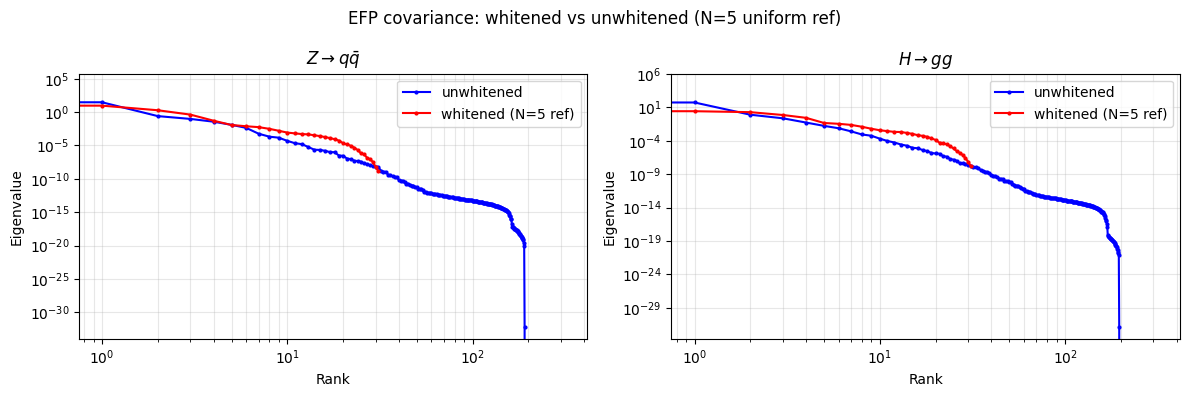

In [46]:
# Whitener from N=5 uniform phase space
W_N5, keep_N5 = compute_whitener(EFP_cov_N5)
print(f'r = {W_N5.shape[1]} directions kept out of {W_N5.shape[0]}')

# Raw Pythia EFP covariances — must use same efpset as section 7 for consistent dimensions
EFPs_Z_raw = efpset.batch_compute(Zqq_events)
EFPs_H_raw = efpset.batch_compute(Hgg_events)
cov_Z_raw  = np.cov(EFPs_Z_raw.T)
cov_H_raw  = np.cov(EFPs_H_raw.T)

# Whitened covariances: W^T C W
cov_Z_white = W_N5.T @ cov_Z_raw @ W_N5
cov_H_white = W_N5.T @ cov_H_raw @ W_N5

# Eigenspectra
eigs_Z_raw   = np.clip(np.sort(np.linalg.eigvalsh(cov_Z_raw))[::-1],   0, None)
eigs_H_raw   = np.clip(np.sort(np.linalg.eigvalsh(cov_H_raw))[::-1],   0, None)
eigs_Z_white = np.clip(np.sort(np.linalg.eigvalsh(cov_Z_white))[::-1], 0, None)
eigs_H_white = np.clip(np.sort(np.linalg.eigvalsh(cov_H_white))[::-1], 0, None)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, eigs_raw, eigs_w, title in zip(
    axes,
    [eigs_Z_raw,            eigs_H_raw],
    [eigs_Z_white,          eigs_H_white],
    [r'$Z \to q\bar{q}$', r'$H \to gg$'],
):
    ax.loglog(eigs_raw, 'b.-', markersize=4, label='unwhitened')
    ax.loglog(eigs_w,   'r.-', markersize=4, label='whitened (N=5 ref)')
    ax.set_title(title); ax.set_xlabel('Rank'); ax.set_ylabel('Eigenvalue')
    ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.suptitle('EFP covariance: whitened vs unwhitened (N=5 uniform ref)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/whitened_eigenspectrum.png', dpi=150, bbox_inches='tight')
plt.show()


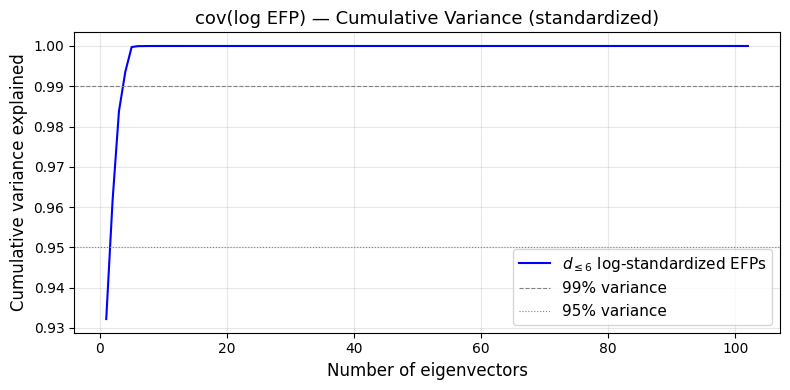

95% variance explained by 2 eigenvectors (out of 102)
99% variance explained by 4 eigenvectors (out of 102)


In [266]:
# Cumulative variance — log-standardized covariance (matches regression)
from sklearn.preprocessing import StandardScaler

X_cum = StandardScaler().fit_transform(np.vstack([efps_Z, efps_H]))
eigvals_cum = np.sort(np.clip(np.linalg.eigvalsh(np.cov(X_cum.T)), 0, None))[::-1]
cum_var = np.cumsum(eigvals_cum) / np.sum(eigvals_cum)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, len(cum_var) + 1), cum_var, 'b-', label=r'$d_{\leq 6}$ log-standardized EFPs')
ax.axhline(0.99, color='gray', linestyle='--', linewidth=0.8, label='99% variance')
ax.axhline(0.95, color='gray', linestyle=':', linewidth=0.8, label='95% variance')
ax.set_xlabel('Number of eigenvectors', fontsize=12)
ax.set_ylabel('Cumulative variance explained', fontsize=12)
ax.set_title('cov(log EFP) — Cumulative Variance (standardized)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/cumulative_variance.png', dpi=150, bbox_inches='tight')
plt.show()

for thresh, label in [(0.95, '95%'), (0.99, '99%')]:
    n = np.searchsorted(cum_var, thresh) + 1
    print(f'{label} variance explained by {n} eigenvectors (out of {len(cum_var)})')